In [1]:
from mdagent import MDAgent

In [2]:
import nest_asyncio
nest_asyncio.apply()

In [3]:
mda = MDAgent(agent_type='Structured', model='gpt-4-1106-preview', use_memory=False, top_k_tools="all")

In [4]:
#llm='gpt-4-1106-preview'
prompt = '''Simulate protein 1ZNI at 300K for 3ns and calculate RMSD.'''

In [5]:
answer = mda.run(prompt)

Thought: To simulate the protein 1ZNI at 300K for 3ns and calculate the RMSD, I will need to set up and run a molecular dynamics simulation using the SetUpandRunFunction tool. After the simulation is complete, I can then use the ComputeRMSD tool to calculate the root mean square deviation. First, I need to set up and run the simulation.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1ZNI",
    "forcefield_files": ["amber14-all.xml", "amber14/tip3pfb.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1 * nanometers",
      "constraints": "HBonds",
      "rigidWater": true,
      "constraintTolerance": 0.00001,
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of

2024-06-29 21:23:54.526 
  command:

    streamlit run /Users/samcox/anaconda3/envs/mda_jun29/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]


Now that I have the file ID for the PDB file of protein 1ZNI, I can proceed to set up and run the molecular dynamics simulation using the SetUpandRunFunction tool with the correct file ID and the necessary parameters, including the constraintTolerance.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1ZNI_212354",
    "forcefield_files": ["amber99sb.xml", "tip3p.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1 * nanometers",
      "constraints": "HBonds",
      "rigidWater": true,
      "constraintTolerance": 0.00001,
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of Steps": 1500000,
      "record_interval_steps": 15000
    }
  }
}
```Setting default ewald

### make sure files actually exist

In [8]:
plot_id = "fig0_225641"
rmsd_csv_id = "rmsd_225404"
traj_id = "rec0_225406"
top_id = "top_sim0_225404"

In [6]:
registry = mda.path_registry

In [9]:
all_names = registry.list_path_names()

In [10]:
all_names

'Names found in registry: 1ZNI_212354, 1ZNI_212410, top_sim0_212420, top_sim0_225127, sim0_225127, top_sim0_225404, sim0_225404, rec0_225406, rec1_225406, rec2_225406, rmsd_225404, fig0_225641'

In [12]:
assert all(substring in all_names for substring in [plot_id, rmsd_csv_id, traj_id, top_id]), "Not all strings are present in the main string"

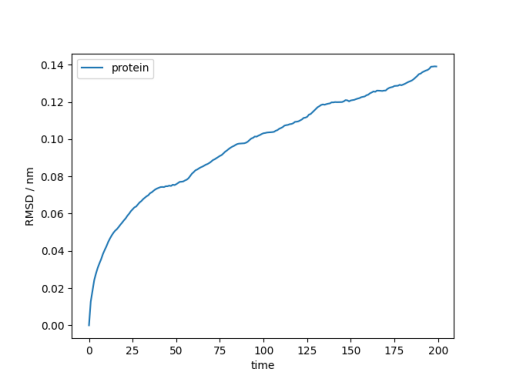

In [17]:
#let's see if we can't grab the plot
%matplotlib inline
plot_path = registry.get_mapped_path(plot_id)

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the image
img = mpimg.imread(plot_path)

# Display the image
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show()